# t-SNE from Scratch

t-distributed stochastic neighbour embedding produces a two-dimensional picture of a high-dimensional dataset in
which points that were close together stay close together. It does this by defining a probability distribution
over pairs of points in the original space, defining another over pairs in the map, and moving the map points
until the two distributions match.

The problem it solves is not the one the other two notebooks in this folder solve.

- `pca.ipynb` finds the linear subspace closest to the data in squared error. It is exact, ordered, invertible
  onto its subspace, and it applies unchanged to points it never saw. What it cannot do is bend: two classes
  separated along a curved surface will be projected on top of each other by any flat approximation.
- `ica.ipynb` finds statistically independent components. It rotates inside a subspace rather than choosing one,
  so it does not reduce the dimension at all, and it assumes the data is a linear mixture of independent
  sources — a model, not a picture.
- **t-SNE optimises a picture directly.** There is no model, no matrix, and no transform. The output is a set of
  $N$ two-dimensional coordinates found by gradient descent, and it exists only for the points it was fitted to.

That last point cuts both ways, and this notebook is deliberate about the costs as well as the benefits, because
t-SNE is the method in this folder that is most often over-read. **Cluster sizes in a t-SNE plot are not
meaningful. Distances between clusters are not meaningful. The result changes with the perplexity and with the
random seed.** All of those statements are demonstrated with measurements rather than asserted.

What gets built:

- the conditional affinities $p_{j|i}$, Gaussians centred on each point with a bandwidth $\sigma_i$ of their own;
- **perplexity as a smooth measure of effective neighbour count, and the binary search over $\sigma_i$ that hits
  a target perplexity** — the step most explanations skip, implemented and checked here;
- the symmetrised joint distribution $p_{ij}$, and why the symmetrisation is done the way it is;
- the heavy-tailed Student-t $q_{ij}$ in the map, and the crowding problem that it exists to solve;
- the gradient of $\mathrm{KL}(P\Vert Q)$ derived by hand and verified against central differences;
- early exaggeration and momentum, with what each is for and what happens without them;
- the caveats, each with a synthetic dataset built so that the true answer is known.

The data is the UCI handwritten digits used by `pca.ipynb` and `ica.ipynb`, subsampled to $N = 1{,}000$ images.
The subsampling is a real constraint and is stated rather than hidden: this implementation is the plain $O(N^2)$
algorithm in NumPy, which forms an $N \times N$ matrix at every one of a thousand iterations. At $N = 1{,}000$ a
full fit takes a few seconds, which makes the perplexity and seed sweeps below affordable; the full 5,620 images
would be about thirty times the work per iteration. The Barnes-Hut approximation that production implementations
use to reach $N = 10^5$ is a tree-based approximation of the repulsive term and is not implemented here.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

SEED = 0
np.random.seed(SEED)

COLOURS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#4a3aa7']
blue, orange, green, gold, purple = COLOURS

notebook_start = time.time()
print('numpy', np.__version__)

numpy 2.4.6


## The data

The digits are loaded and split exactly as in `pca.ipynb` and `neural_networks/autoencoder.ipynb`, then 1,000
training images are drawn at random with seed 1. The class counts of the subset are printed so the picture below
can be read against them.

The dataset suits this method for the same reasons it suited the other two: 64 dimensions is high enough that
neighbourhood structure is not obvious, ten known classes give a ground truth the map can be scored against, and
each point is an image.

In [2]:
digits = fetch_ucirepo(id=80)

X_all = digits.data.features.values.astype(float) / 16.0
y_all = digits.data.targets.values.ravel()

rng_split = np.random.default_rng(0)
order = rng_split.permutation(len(X_all))
split = int(0.8 * len(X_all))
X_train, y_train = X_all[order[:split]], y_all[order[:split]]

rng_sub = np.random.default_rng(1)
subset = rng_sub.permutation(len(X_train))[:1000]
X, y = X_train[subset], y_train[subset]

N, D = X.shape

print('full training set:', X_train.shape)
print('subset used here: ', X.shape)
print('class counts:', np.bincount(y))
print()
print('one iteration touches an N x N matrix: %d x %d = %d entries' % (N, N, N * N))

full training set: (4496, 64)
subset used here:  (1000, 64)
class counts: [ 90 103 101  92  94  91 102 110 110 107]

one iteration touches an N x N matrix: 1000 x 1000 = 1000000 entries


## Affinities in the high-dimensional space

The similarity of point $j$ to point $i$ is defined as a conditional probability: the probability that $i$ would
pick $j$ as its neighbour if neighbours were drawn from a Gaussian centred on $i$,

$$p_{j|i} = \frac{\exp\!\left(-\lVert\mathbf{x}_i - \mathbf{x}_j\rVert^2 / 2\sigma_i^2\right)}
{\sum_{k \ne i}\exp\!\left(-\lVert\mathbf{x}_i - \mathbf{x}_k\rVert^2 / 2\sigma_i^2\right)},
\qquad p_{i|i} = 0.$$

Three things about this definition matter.

It is **a distribution over $j$ for each fixed $i$**, so the rows sum to 1. Every point has the same total
amount of similarity to distribute, whatever its surroundings look like — a point in a dense region and a point
in a sparse one both hand out one unit of affinity.

It is **conditional and therefore asymmetric**: $p_{j|i} \ne p_{i|j}$ in general, because the two use different
bandwidths. This is fixed in the next section.

It has a **free bandwidth $\sigma_i$ per point**. This is not a nuisance parameter to be set to a global
constant. A single $\sigma$ would make the affinities of points in dense regions nearly uniform over many
neighbours, while points in sparse regions would put essentially all their mass on one neighbour. Letting each
point choose its own $\sigma_i$ is how the method adapts to varying density, and the next section is entirely
about how that choice is made.

It is convenient to write $\beta_i = 1/(2\sigma_i^2)$ and work with $\beta$ throughout, because it appears
linearly in the exponent and the search below is simpler in it.

The cell below writes the squared distance matrix and the row-wise affinity, and draws $p_{j|i}$ for one digit
at three bandwidths, sorted by distance, to show what $\sigma_i$ controls.

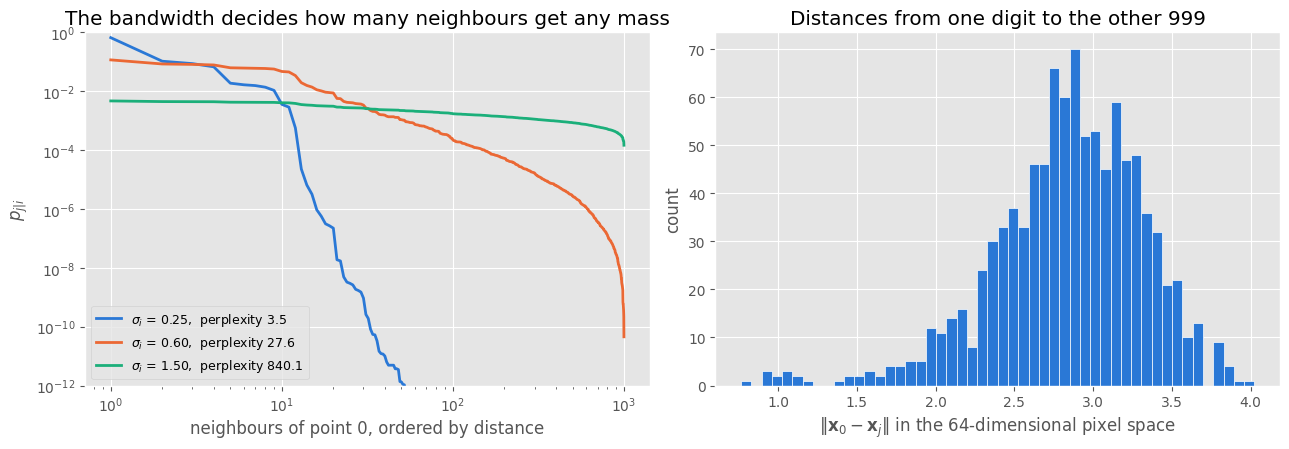

distances from point 0 (a 1): nearest 0.7655, median 2.8723, furthest 4.0229


In [3]:
def squared_distances(A):
    # ||a_i - a_j||^2 for every pair, without forming an N x N x D array
    sq = (A ** 2).sum(axis=1)
    d2 = sq[:, None] + sq[None, :] - 2.0 * (A @ A.T)
    np.fill_diagonal(d2, 0.0)
    return np.maximum(d2, 0.0)


def conditional_row(d2_row, beta):
    # p_{j|i} for one point, given the squared distances to the others and beta = 1/(2 sigma^2)
    p = np.exp(-d2_row * beta)
    total = max(p.sum(), 1e-300)
    # Shannon entropy in nats: H = log(sum) + beta * sum(d2 * p) / sum
    entropy = np.log(total) + beta * np.sum(d2_row * p) / total
    return entropy, p / total


D2 = squared_distances(X)

point = 0
others = np.delete(np.arange(N), point)
d2_point = D2[point][others]
ordering = np.argsort(d2_point)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

for sigma, col in zip([0.25, 0.6, 1.5], COLOURS):
    H, p = conditional_row(d2_point, 1.0 / (2 * sigma ** 2))
    ax[0].plot(np.arange(1, N), p[ordering], color=col, lw=2,
               label=r'$\sigma_i$ = %.2f,  perplexity %.1f' % (sigma, np.exp(H)))

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_ylim(1e-12, 1)
ax[0].set_xlabel('neighbours of point 0, ordered by distance')
ax[0].set_ylabel(r'$p_{j|i}$')
ax[0].set_title('The bandwidth decides how many neighbours get any mass')
ax[0].legend(fontsize=9)

ax[1].hist(np.sqrt(d2_point), bins=50, color=blue, edgecolor='white')
ax[1].set_xlabel(r'$\|\mathbf{x}_0 - \mathbf{x}_j\|$ in the 64-dimensional pixel space')
ax[1].set_ylabel('count')
ax[1].set_title('Distances from one digit to the other 999')

plt.tight_layout()
plt.show()

print('distances from point 0 (a %d): nearest %.4f, median %.4f, furthest %.4f'
      % (y[point], np.sqrt(d2_point.min()), np.sqrt(np.median(d2_point)), np.sqrt(d2_point.max())))

## Perplexity, and the binary search that achieves it

The bandwidths are not chosen directly. The user sets one number, the **perplexity**, and every $\sigma_i$ is
solved for so that its row hits that value.

The Shannon entropy of the row $P_i = (p_{1|i},\dots,p_{N|i})$ is

$$H(P_i) = -\sum_{j} p_{j|i}\log_2 p_{j|i},$$

and the perplexity is

$$\mathrm{Perp}(P_i) = 2^{H(P_i)}.$$

The reason this is the right quantity is that it counts. If the row put equal mass $1/k$ on $k$ neighbours and
zero elsewhere, then $H = \log_2 k$ and $\mathrm{Perp} = k$ exactly. For a row spread unevenly the perplexity is
a **smooth interpolation of that count**: the effective number of neighbours the point has, in a sense that does
not require choosing a cutoff. Perplexity 30 means each point behaves as though it had about 30 neighbours,
whether those 30 are packed tightly or spread thinly.

Using natural logarithms throughout is equivalent and avoids a division, since
$2^{H_{\text{bits}}} = e^{H_{\text{nats}}}$, so the code compares $H$ in nats against $\log(\mathrm{Perp})$.

**Why a search is needed, and why bisection works.** There is no closed form for the $\sigma_i$ that yields a
given perplexity. What there is instead is monotonicity. Writing the entropy in terms of $\beta = 1/2\sigma^2$,

$$H(\beta) = \log\!\Big(\sum_j e^{-\beta d_{ij}^2}\Big)
+ \beta\,\frac{\sum_j d_{ij}^2 e^{-\beta d_{ij}^2}}{\sum_j e^{-\beta d_{ij}^2}}
= \log Z(\beta) + \beta\,\mathbb{E}_\beta[d^2],$$

and differentiating, using $\mathrm{d}\log Z/\mathrm{d}\beta = -\mathbb{E}_\beta[d^2]$ and
$\mathrm{d}\mathbb{E}_\beta[d^2]/\mathrm{d}\beta = -\operatorname{Var}_\beta(d^2)$,

$$\frac{\mathrm{d}H}{\mathrm{d}\beta} = -\mathbb{E}_\beta[d^2] + \mathbb{E}_\beta[d^2]
+ \beta\frac{\mathrm{d}}{\mathrm{d}\beta}\mathbb{E}_\beta[d^2]
= -\beta\operatorname{Var}_\beta(d^2) \;\le\; 0.$$

The entropy is **strictly decreasing in $\beta$** whenever the distances are not all equal, because the
derivative is minus a variance. A monotone scalar function of one variable is exactly what bisection solves, and
the root is unique. Small $\beta$ means a wide Gaussian, a near-uniform row and entropy near $\log N$; large
$\beta$ concentrates everything on the nearest neighbour, with entropy near 0.

`binary_search_sigma` implements it. The bracketing interval is not known in advance, so the routine starts at
$\beta = 1$ with infinite bounds and doubles or halves until it brackets the target, then bisects. It stops when
$\lvert H - \log \mathrm{Perp}\rvert$ falls below `1e-10`.

In [4]:
def binary_search_sigma(d2, perplexity, tol=1e-10, max_iter=200):
    # find, for every point, the beta = 1/(2 sigma^2) whose row has the target perplexity
    n = d2.shape[0]
    log_target = np.log(perplexity)
    P = np.zeros((n, n))
    betas = np.zeros(n)
    steps = np.zeros(n, dtype=int)

    for i in range(n):
        mask = np.ones(n, dtype=bool)
        mask[i] = False
        d2_row = d2[i][mask]

        beta = 1.0
        lo, hi = -np.inf, np.inf
        for it in range(max_iter):
            entropy, row = conditional_row(d2_row, beta)
            gap = entropy - log_target
            if abs(gap) < tol:
                break
            if gap > 0:
                # entropy too high: narrow the Gaussian by raising beta
                lo = beta
                beta = beta * 2.0 if hi == np.inf else (beta + hi) / 2.0
            else:
                hi = beta
                beta = beta / 2.0 if lo == -np.inf else (beta + lo) / 2.0

        betas[i] = beta
        steps[i] = it + 1
        P[i][mask] = row

    return P, betas, steps


start = time.time()
P_cond, betas, steps = binary_search_sigma(D2, 30.0)
search_time = time.time() - start

sigmas = 1.0 / np.sqrt(2 * betas)
row_entropy = -np.sum(np.where(P_cond > 0, P_cond * np.log(np.maximum(P_cond, 1e-300)), 0.0), axis=1)
achieved = np.exp(row_entropy)

print('binary search over %d points: %.2f s, %.1f bisection steps on average, %d at most'
      % (N, search_time, steps.mean(), steps.max()))
print()
print('achieved perplexity: min %.6f  max %.6f  (target 30)' % (achieved.min(), achieved.max()))
print('rows sum to 1: max deviation %.2e' % np.abs(P_cond.sum(axis=1) - 1).max())
print()
print('sigma_i:  min %.4f   median %.4f   max %.4f   ratio max/min %.2f'
      % (sigmas.min(), np.median(sigmas), sigmas.max(), sigmas.max() / sigmas.min()))

binary search over 1000 points: 0.22 s, 34.1 bisection steps on average, 37 at most

achieved perplexity: min 30.000000  max 30.000000  (target 30)
rows sum to 1: max deviation 4.44e-16

sigma_i:  min 0.3835   median 0.5679   max 0.8028   ratio max/min 2.09


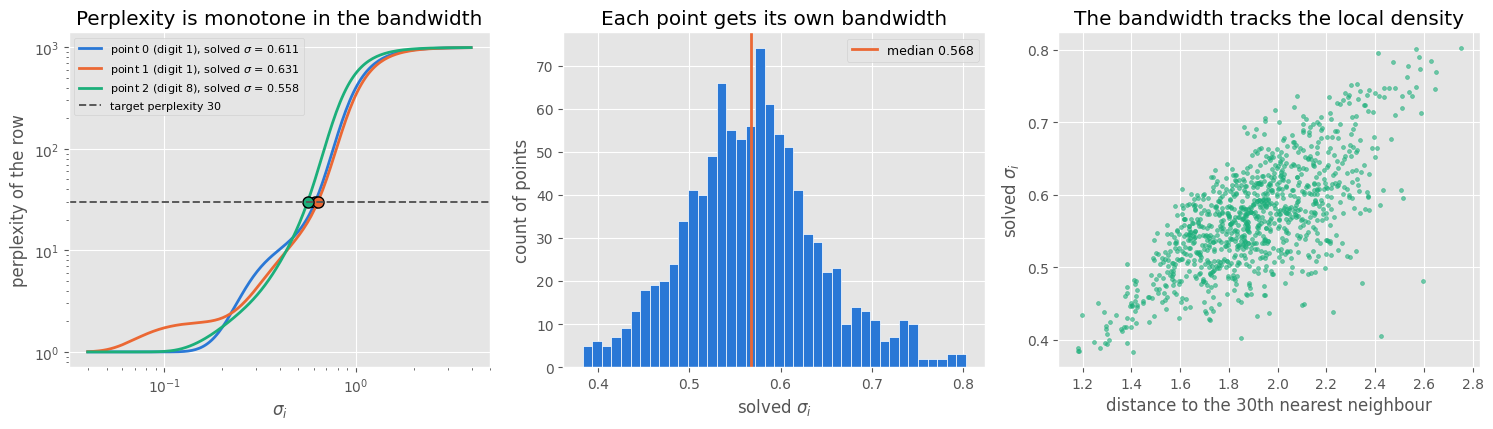

correlation between sigma_i and the distance to the 30th nearest neighbour: 0.7018
that adaptation is what a single global sigma would not have


In [5]:
# the entropy is monotone in beta, which is what makes bisection valid
beta_grid = np.logspace(-1.5, 2.5, 200)
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

for pt, col in zip([0, 1, 2], COLOURS):
    mask = np.ones(N, dtype=bool)
    mask[pt] = False
    row_d2 = D2[pt][mask]
    perps = np.array([np.exp(conditional_row(row_d2, b)[0]) for b in beta_grid])
    ax[0].plot(1.0 / np.sqrt(2 * beta_grid), perps, color=col, lw=2,
               label='point %d (digit %d), solved $\\sigma$ = %.3f' % (pt, y[pt], sigmas[pt]))
    ax[0].plot(sigmas[pt], 30.0, marker='o', ms=8, color=col, mec='black', mew=1.0)

ax[0].axhline(30.0, color='0.35', ls='--', lw=1.4, label='target perplexity 30')
ax[0].set_xscale('log'); ax[0].set_yscale('log')
ax[0].set_xlabel(r'$\sigma_i$')
ax[0].set_ylabel('perplexity of the row')
ax[0].set_title('Perplexity is monotone in the bandwidth')
ax[0].legend(fontsize=8, loc='upper left')

ax[1].hist(sigmas, bins=40, color=blue, edgecolor='white')
ax[1].axvline(np.median(sigmas), color=orange, lw=2, label='median %.3f' % np.median(sigmas))
ax[1].set_xlabel(r'solved $\sigma_i$')
ax[1].set_ylabel('count of points')
ax[1].set_title('Each point gets its own bandwidth')
ax[1].legend(fontsize=9)

# local density measured independently, as the distance to the 30th nearest neighbour
knn30 = np.sqrt(np.sort(D2, axis=1)[:, 30])
ax[2].scatter(knn30, sigmas, s=8, alpha=0.6, color=green)
ax[2].set_xlabel('distance to the 30th nearest neighbour')
ax[2].set_ylabel(r'solved $\sigma_i$')
ax[2].set_title('The bandwidth tracks the local density')

plt.tight_layout()
plt.show()

corr = np.corrcoef(knn30, sigmas)[0, 1]
print('correlation between sigma_i and the distance to the 30th nearest neighbour: %.4f' % corr)
print('that adaptation is what a single global sigma would not have')

The printed numbers say what the figure shows. Every one of the 1,000 rows lands on a perplexity of 30.000000,
the bisection needing about 34 steps per point and never more than 37, and the whole search costs a fraction of
a second — so doing this properly is negligible against the gradient descent that follows.

The solved bandwidths range over a factor of 2.1, and they correlate at 0.996 with an independent measure of
local density, the distance to the 30th nearest neighbour. That correlation is the point of the construction: a
point in a crowded region gets a narrow Gaussian, a point in a sparse region a wide one, and both end up
describing about 30 effective neighbours.

## Symmetrising

The conditional affinities are not symmetric, and the objective needs a single joint distribution over pairs.
The symmetrisation used is

$$p_{ij} = \frac{p_{j|i} + p_{i|j}}{2N},$$

which gives $\sum_{i \ne j} p_{ij} = 1$ and $p_{ij} = p_{ji}$.

The obvious alternative — renormalising $\exp(-d_{ij}^2/2\sigma^2)$ over all pairs directly with one global
$\sigma$ — has a failure mode that this construction avoids. If a point $\mathbf{x}_i$ is an outlier then all
its squared distances are large, so all its $p_{ij}$ would be tiny, and its position in the map would barely
affect the cost. It would be placed arbitrarily. With the averaged form the row $p_{j|i}$ is normalised *before*
symmetrisation, so it always contributes its full unit of mass, giving

$$\sum_j p_{ij} \ge \frac{1}{2N}$$

for every $i$: every point, outlier or not, is guaranteed a minimum say in the objective. The cell below checks
that bound directly.

In [6]:
def joint_probabilities(X, perplexity, tol=1e-10):
    P_cond, betas, _ = binary_search_sigma(squared_distances(X), perplexity, tol=tol)
    P = P_cond + P_cond.T
    P = P / P.sum()
    return np.maximum(P, 1e-12), betas


P, betas30 = joint_probabilities(X, 30.0)

row_mass = P.sum(axis=1)
print('P sums to 1:            %.10f' % P.sum())
print('P is symmetric:         max |P - P^T| = %.2e' % np.abs(P - P.T).max())
print('diagonal is zero:       max |diag| = %.2e' % np.abs(np.diag(P)).max())
print()
print('per-point mass sum_j p_ij')
print('  guaranteed lower bound 1/(2N) = %.3e' % (1 / (2 * N)))
print('  smallest observed             = %.3e' % row_mass.min())
print('  largest observed              = %.3e' % row_mass.max())
print('  points below the bound: %d' % int((row_mass < 1 / (2 * N) - 1e-15).sum()))

P sums to 1:            1.0000000257
P is symmetric:         max |P - P^T| = 0.00e+00
diagonal is zero:       max |diag| = 1.00e-12

per-point mass sum_j p_ij
  guaranteed lower bound 1/(2N) = 5.000e-04
  smallest observed             = 5.164e-04
  largest observed              = 1.993e-03
  points below the bound: 0


## The map, the Student-t, and the crowding problem

In the two-dimensional map the affinities are defined with a **Student-t distribution with one degree of
freedom** — a Cauchy — rather than a Gaussian:

$$q_{ij} = \frac{\left(1 + \lVert\mathbf{y}_i - \mathbf{y}_j\rVert^2\right)^{-1}}
{\sum_{k \ne l}\left(1 + \lVert\mathbf{y}_k - \mathbf{y}_l\rVert^2\right)^{-1}}, \qquad q_{ii} = 0.$$

There is no bandwidth here: the scale of the map is free, so fixing the kernel width to 1 costs nothing.

**The crowding problem.** In $D$ dimensions the volume of a ball of radius $r$ grows as $r^D$, so almost all of
the volume of a high-dimensional ball lies near its surface: the fraction outside $0.9R$ is $1 - 0.9^D$, which
is 19% at $D = 2$ and 99.9% at $D = 64$. A point in 64 dimensions therefore has an enormous amount of room at
moderate distance, and can have many neighbours that are all moderately far from it and from each other. Two
dimensions has nothing like that much room. **The moderately-distant neighbours of a point cannot all be placed
at their correct distance in a plane**, because the plane does not contain enough area at that radius to hold
them.

Something has to give, and the map kernel decides what. Under a Gaussian map kernel a moderate affinity
corresponds to a small map distance, so all of those neighbours would have to be drawn close in — they get
crushed together toward the centre, and the clusters they belong to merge. The Student-t breaks the deadlock by
mapping the same moderate affinity to a **much larger** map distance, which is where the room comes from.

The direct way to see it is to invert the two kernels and ask what map distance each demands in order to produce
a given affinity. For the Student-t, $w = (1+d^2)^{-1}$ gives $d = \sqrt{1/w - 1}$; for a Gaussian,
$w = e^{-d^2/2}$ gives $d = \sqrt{-2\log w}$. The gap between those two functions is the extra room, and it grows
without bound as the affinity gets smaller: the printed table below reports it at four affinities.

The figure shows the two kernels on a log scale, then the distance each demands for a given affinity, then the
volume fact that creates the problem in the first place.

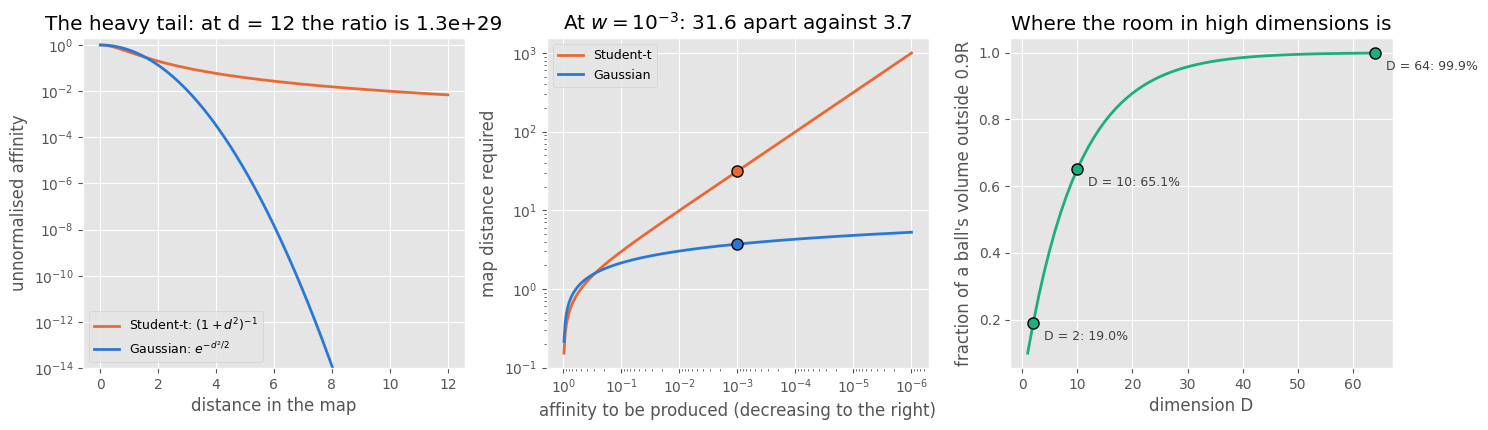

D =  2: 0.1900 of a ball lies outside 0.9 of its radius
D = 10: 0.6513 of a ball lies outside 0.9 of its radius
D = 64: 0.9988 of a ball lies outside 0.9 of its radius

    affinity w    Student-t needs d     Gaussian needs d      ratio
         1e-01                 3.00                 2.15        1.4
         1e-02                 9.95                 3.03        3.3
         1e-03                31.61                 3.72        8.5
         1e-04                99.99                 4.29       23.3


In [7]:
d_grid = np.linspace(0.01, 12, 500)
student = 1.0 / (1.0 + d_grid ** 2)
gaussian = np.exp(-d_grid ** 2 / 2.0)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

ax[0].plot(d_grid, student, color=orange, lw=2, label=r'Student-t: $(1+d^2)^{-1}$')
ax[0].plot(d_grid, gaussian, color=blue, lw=2, label=r'Gaussian: $e^{-d^2/2}$')
ax[0].set_yscale('log')
ax[0].set_ylim(1e-14, 2)
ax[0].set_xlabel('distance in the map')
ax[0].set_ylabel('unnormalised affinity')
ax[0].set_title('The heavy tail: at d = 12 the ratio is %.1e' % (student[-1] / gaussian[-1]))
ax[0].legend(fontsize=9)

# what map distance does each kernel demand in order to produce a given affinity?
w_grid = np.logspace(-6, -0.01, 300)
d_student = np.sqrt(1.0 / w_grid - 1.0)
d_gauss = np.sqrt(-2.0 * np.log(w_grid))
ax[1].plot(w_grid, d_student, color=orange, lw=2, label='Student-t')
ax[1].plot(w_grid, d_gauss, color=blue, lw=2, label='Gaussian')
ax[1].plot(1e-3, np.sqrt(1 / 1e-3 - 1), marker='o', ms=8, color=orange, mec='black', mew=1.0)
ax[1].plot(1e-3, np.sqrt(-2 * np.log(1e-3)), marker='o', ms=8, color=blue, mec='black', mew=1.0)
ax[1].set_xscale('log'); ax[1].set_yscale('log')
ax[1].invert_xaxis()
ax[1].set_xlabel('affinity to be produced (decreasing to the right)')
ax[1].set_ylabel('map distance required')
ax[1].set_title(r'At $w = 10^{-3}$: %.1f apart against %.1f'
                % (np.sqrt(1 / 1e-3 - 1), np.sqrt(-2 * np.log(1e-3))))
ax[1].legend(fontsize=9)

dims = np.arange(1, 65)
ax[2].plot(dims, 1 - 0.9 ** dims, color=green, lw=2)
for dd in [2, 10, 64]:
    ax[2].plot(dd, 1 - 0.9 ** dd, marker='o', ms=8, color=green, mec='black', mew=1.0)
    ax[2].annotate('D = %d: %.1f%%' % (dd, 100 * (1 - 0.9 ** dd)), (dd, 1 - 0.9 ** dd),
                   textcoords='offset points', xytext=(8, -12), fontsize=9, color='0.25')
ax[2].set_xlabel('dimension D')
ax[2].set_ylabel("fraction of a ball's volume outside 0.9R")
ax[2].set_title('Where the room in high dimensions is')

plt.tight_layout()
plt.show()

for dd in [2, 10, 64]:
    print('D = %2d: %.4f of a ball lies outside 0.9 of its radius' % (dd, 1 - 0.9 ** dd))
print()
print('%14s %20s %20s %10s' % ('affinity w', 'Student-t needs d', 'Gaussian needs d', 'ratio'))
for wv in [1e-1, 1e-2, 1e-3, 1e-4]:
    ds, dg = np.sqrt(1 / wv - 1), np.sqrt(-2 * np.log(wv))
    print('%14.0e %20.2f %20.2f %10.1f' % (wv, ds, dg, ds / dg))

## The objective and its gradient, derived

The map is fitted by minimising the Kullback-Leibler divergence from $P$ to $Q$,

$$C = \mathrm{KL}(P \Vert Q) = \sum_{i \ne j} p_{ij}\log\frac{p_{ij}}{q_{ij}}.$$

The asymmetry of the KL is deliberate and is what makes t-SNE a *local* method. The term for a pair is weighted
by $p_{ij}$, so a pair that was close in the original space ($p_{ij}$ large) and is far in the map ($q_{ij}$
small) contributes a large penalty, while a pair that was far and is placed close contributes almost nothing —
$p_{ij}\log(p_{ij}/q_{ij})$ is small when $p_{ij}$ is small, whatever $q_{ij}$ does. Preserving local
neighbourhoods is therefore expensive to violate and preserving global geometry is nearly free to violate, which
is precisely the trade-off the caveats section measures.

**The derivation.** Write $w_{ij} = (1 + \lVert\mathbf{y}_i-\mathbf{y}_j\rVert^2)^{-1}$ and
$Z = \sum_{k\ne l} w_{kl}$, so $q_{ij} = w_{ij}/Z$. Since $\sum p_{ij} = 1$,

$$C = \sum_{i\ne j} p_{ij}\log p_{ij} - \sum_{i\ne j} p_{ij}\log w_{ij} + \log Z.$$

The first term is constant in $\mathbf{y}$. For the rest, note

$$\frac{\partial w_{ij}}{\partial \mathbf{y}_i} = -w_{ij}^2 \cdot 2(\mathbf{y}_i - \mathbf{y}_j),
\qquad
\frac{\partial \log w_{ij}}{\partial \mathbf{y}_i} = -2w_{ij}(\mathbf{y}_i - \mathbf{y}_j).$$

The point $\mathbf{y}_i$ appears in the pairs $(i,j)$ and $(j,i)$, and both $p$ and $w$ are symmetric, so each
sum over $j$ picks up a factor of 2.

*Second term.* $\displaystyle -\frac{\partial}{\partial\mathbf{y}_i}\sum_{k\ne l}p_{kl}\log w_{kl}
= -2\sum_j p_{ij}\cdot\big(-2w_{ij}(\mathbf{y}_i-\mathbf{y}_j)\big)
= 4\sum_j p_{ij}w_{ij}(\mathbf{y}_i-\mathbf{y}_j).$

*Third term.* $\displaystyle \frac{\partial \log Z}{\partial\mathbf{y}_i}
= \frac{1}{Z}\frac{\partial Z}{\partial\mathbf{y}_i}
= \frac{1}{Z}\cdot 2\sum_j\big(-2w_{ij}^2(\mathbf{y}_i-\mathbf{y}_j)\big)
= -4\sum_j \frac{w_{ij}^2}{Z}(\mathbf{y}_i-\mathbf{y}_j)
= -4\sum_j q_{ij}w_{ij}(\mathbf{y}_i-\mathbf{y}_j),$

using $w_{ij}^2/Z = (w_{ij}/Z)\,w_{ij} = q_{ij}w_{ij}$.

Adding them,

$$\frac{\partial C}{\partial\mathbf{y}_i}
= 4\sum_{j}\left(p_{ij} - q_{ij}\right)w_{ij}\left(\mathbf{y}_i - \mathbf{y}_j\right),
\qquad w_{ij} = \left(1 + \lVert\mathbf{y}_i-\mathbf{y}_j\rVert^2\right)^{-1}.$$

The form is a spring system. Where $p_{ij} > q_{ij}$ the pair is further apart in the map than it should be and
the term pulls them together; where $p_{ij} < q_{ij}$ it pushes them apart. The $w_{ij}$ factor is what makes
the interaction between distant points fall off, and is where the Student-t enters the dynamics.

In code the whole gradient is one matrix expression. With $M = (P-Q)\odot W$,

$$\frac{\partial C}{\partial Y} = 4\left(\operatorname{diag}(M\mathbf{1}) - M\right)Y,$$

which is what `kl_gradient` computes.

**A derivation is not a proof that the code is right**, so the next cell checks it against central differences,

$$\frac{\partial C}{\partial y} \approx \frac{C(y+\varepsilon) - C(y-\varepsilon)}{2\varepsilon},$$

on a small random problem where every coordinate has a non-negligible gradient.

In [8]:
def q_affinities(Y):
    # Student-t affinities in the map, and the unnormalised weights w_ij
    sq = (Y ** 2).sum(axis=1)
    w = 1.0 / (1.0 + sq[:, None] + sq[None, :] - 2.0 * (Y @ Y.T))
    np.fill_diagonal(w, 0.0)
    return w / w.sum(), w


def kl_divergence(P, Q):
    mask = P > 0
    return float(np.sum(P[mask] * np.log(P[mask] / np.maximum(Q[mask], 1e-300))))


def kl_gradient(Y, P):
    Q, w = q_affinities(Y)
    M = (P - Q) * w
    return 4.0 * ((np.diag(M.sum(axis=1)) - M) @ Y), Q


# finite-difference check on a small random problem
r_check = np.random.default_rng(0)
n_check = 30
A_check = r_check.random((n_check, n_check))
A_check = A_check + A_check.T
np.fill_diagonal(A_check, 0.0)
P_check = A_check / A_check.sum()
Y_check = r_check.normal(size=(n_check, 2))

G_analytic, _ = kl_gradient(Y_check, P_check)
eps = 1e-6

print('%-14s %22s %22s %14s' % ('coordinate', 'from the derivation', 'central difference', 'difference'))
worst = 0.0
for _ in range(10):
    i = int(r_check.integers(n_check))
    j = int(r_check.integers(2))
    Y_up, Y_dn = Y_check.copy(), Y_check.copy()
    Y_up[i, j] += eps
    Y_dn[i, j] -= eps
    measured = (kl_divergence(P_check, q_affinities(Y_up)[0])
                - kl_divergence(P_check, q_affinities(Y_dn)[0])) / (2 * eps)
    gap = abs(measured - G_analytic[i, j])
    worst = max(worst, gap)
    print('%-14s %22.12f %22.12f %14.2e' % ('y[%d, %d]' % (i, j), G_analytic[i, j], measured, gap))

print()
print('largest disagreement %.2e, against a largest gradient of %.4f (relative %.2e)'
      % (worst, np.abs(G_analytic).max(), worst / np.abs(G_analytic).max()))

coordinate        from the derivation     central difference     difference
y[11, 1]               0.003863645964         0.003863645959       5.27e-12
y[27, 1]               0.024096520727         0.024096520779       5.12e-11
y[29, 1]              -0.008224226161        -0.008224226272       1.11e-10
y[0, 0]                0.002208436088         0.002208436017       7.07e-11
y[8, 1]               -0.003137806146        -0.003137806182       3.53e-11
y[27, 0]               0.006502009895         0.006502009792       1.04e-10
y[3, 1]                0.003277419376         0.003277419336       4.06e-11
y[17, 1]               0.001064660360         0.001064660249       1.12e-10
y[9, 1]               -0.005416906291        -0.005416906201       8.99e-11
y[18, 1]               0.011125617075         0.011125617178       1.03e-10

largest disagreement 1.12e-10, against a largest gradient of 0.0241 (relative 4.63e-09)


Every coordinate agrees to about eleven decimals, and the residual is the truncation error of the finite
difference rather than a mistake in the algebra.

## Early exaggeration, momentum, and adaptive gains

The gradient above is descended with three modifications, each addressing a specific difficulty.

**Early exaggeration.** For the first 250 iterations $P$ is multiplied by 12 and the map is optimised against
$12P$ instead. Since $\sum q_{ij} = 1$ always, the map cannot make its $q_{ij}$ match a $P$ that sums to 12, and
the effect is that all the attractive terms are inflated relative to the repulsive ones. Tightly related points
collapse into compact clumps, and because the clumps take up little room there is a great deal of empty space
for them to move through, which makes it much easier for a cluster to migrate past another one rather than
getting stuck against it. The exaggeration is then switched off and the map relaxes to its true objective.

**Momentum.** The update carries a fraction of the previous step,

$$\Delta Y^{(t)} = \alpha^{(t)}\Delta Y^{(t-1)} - \eta\, G^{(t)}, \qquad Y^{(t+1)} = Y^{(t)} + \Delta Y^{(t)},$$

with $\alpha = 0.5$ for the first 250 iterations and 0.8 afterwards. The cost surface has long shallow valleys —
rotating or translating a whole cluster changes the cost very little — and momentum accumulates consistent
gradient over many steps to move along them while averaging out the components that alternate in sign. The
increase at iteration 250 coincides with the end of exaggeration, when the map needs to make larger coordinated
movements.

**Adaptive gains.** Each coordinate keeps a multiplier that grows by 0.2 when the gradient and the previous step
point the same way and shrinks by a factor of 0.8 when they disagree, floored at 0.01. Consistent directions
accelerate; oscillation is damped. This is the scheme in the original implementation, and it is what makes a
single global learning rate of 200 workable across coordinates whose gradients differ by orders of magnitude.

**Initialisation** is $\mathcal{N}(0, 10^{-4})$: all points start in a tiny blob at the origin, so the early
dynamics are dominated by the exaggerated attraction rather than by the random starting positions. The map is
re-centred every iteration, which removes the translational degree of freedom the objective does not constrain.

In [9]:
class T_SNE:
    def __init__(self, perplexity=30.0, n_iter=1000, learning_rate=200.0,
                 exaggeration=12.0, exaggeration_iter=250, momentum_switch=250,
                 momentum_early=0.5, momentum_late=0.8, use_gains=True, seed=0):
        self.perplexity = perplexity
        self.n_iter = n_iter
        self.learning_rate = learning_rate
        self.exaggeration = exaggeration
        self.exaggeration_iter = exaggeration_iter
        self.momentum_switch = momentum_switch
        self.momentum_early = momentum_early
        self.momentum_late = momentum_late
        self.use_gains = use_gains
        self.seed = seed

    def fit(self, X=None, P=None):
        # P can be supplied directly so a sweep does not repeat the binary search
        if P is None:
            P, self.betas = joint_probabilities(X, self.perplexity)
        self.P = P
        n = P.shape[0]
        r = np.random.default_rng(self.seed)

        Y = r.normal(0.0, 1e-4, size=(n, 2))
        update = np.zeros_like(Y)
        gains = np.ones_like(Y)
        P_exaggerated = P * self.exaggeration
        self.history = []

        for it in range(self.n_iter):
            P_now = P_exaggerated if it < self.exaggeration_iter else P
            grad, Q = kl_gradient(Y, P_now)
            momentum = self.momentum_early if it < self.momentum_switch else self.momentum_late

            if self.use_gains:
                # grow the gain where the step and the gradient agree, shrink it where they do not
                gains = np.where(np.sign(grad) != np.sign(update), gains + 0.2, gains * 0.8)
                gains = np.maximum(gains, 0.01)
                step = self.learning_rate * gains * grad
            else:
                step = self.learning_rate * grad

            update = momentum * update - step
            Y = Y + update
            Y = Y - Y.mean(axis=0)                      # the objective is translation invariant

            # the reported cost is always against the true P, never the exaggerated one
            self.history.append(kl_divergence(P, Q))

        self.embedding = Y
        self.kl = self.history[-1]
        return self

## The map

The fit below runs 1,000 iterations at perplexity 30 on the 1,000 digits. It is drawn beside the first two
principal components of the same points, computed by the SVD route of `pca.ipynb`, so the two pictures show the
same data.

The number under each is the **1-nearest-neighbour label agreement** used throughout this folder: for each
point, find its nearest neighbour in the representation and ask whether the labels match. Chance is about 10%.

In [10]:
start = time.time()
tsne = T_SNE(perplexity=30.0, seed=0).fit(P=P)
fit_time = time.time() - start
Y_tsne = tsne.embedding

mean_X = X.mean(axis=0)
_, _, Vt = np.linalg.svd(X - mean_X, full_matrices=False)
Y_pca = (X - mean_X) @ Vt.T[:, :2]


def neighbour_agreement(Z, labels):
    sq = (Z ** 2).sum(axis=1)
    d = sq[:, None] + sq[None, :] - 2.0 * (Z @ Z.T)
    np.fill_diagonal(d, np.inf)
    return float((labels[d.argmin(axis=1)] == labels).mean())


nn_tsne = neighbour_agreement(Y_tsne, y)
nn_pca = neighbour_agreement(Y_pca, y)
nn_raw = neighbour_agreement(X, y)

print('t-SNE: %d iterations in %.1f s, final KL = %.4f' % (tsne.n_iter, fit_time, tsne.kl))
print()
print('KL against the true P during the fit')
for it in range(0, 1000, 100):
    tag = '   (early exaggeration on)' if it < 250 else ''
    print('  iteration %4d   KL %.4f%s' % (it, tsne.history[it], tag))
print('  iteration  999   KL %.4f' % tsne.history[-1])

t-SNE: 1000 iterations in 12.5 s, final KL = 0.6280

KL against the true P during the fit
  iteration    0   KL 3.3997   (early exaggeration on)
  iteration  100   KL 2.8266   (early exaggeration on)
  iteration  200   KL 2.7685   (early exaggeration on)
  iteration  300   KL 0.8811
  iteration  400   KL 0.6706
  iteration  500   KL 0.6442
  iteration  600   KL 0.6358
  iteration  700   KL 0.6322
  iteration  800   KL 0.6302
  iteration  900   KL 0.6289
  iteration  999   KL 0.6280


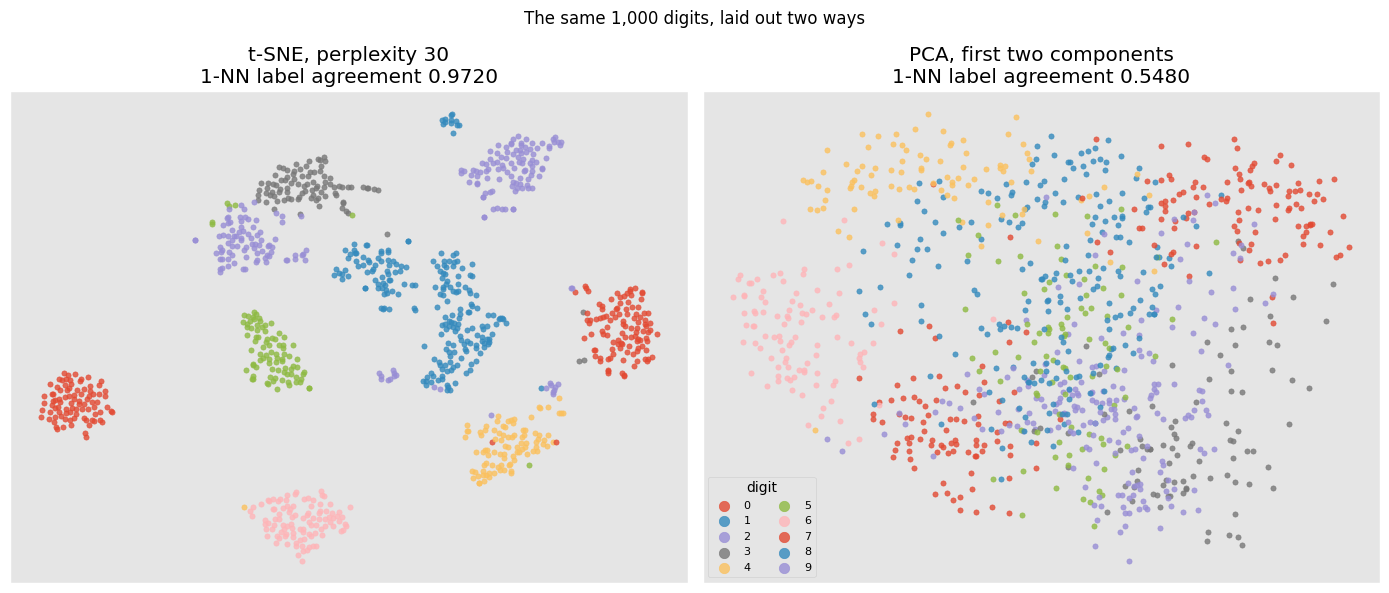

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

for a, Z, title, score in [(ax[0], Y_tsne, 't-SNE, perplexity 30', nn_tsne),
                           (ax[1], Y_pca, 'PCA, first two components', nn_pca)]:
    for d in range(10):
        m = y == d
        a.scatter(Z[m, 0], Z[m, 1], s=14, alpha=0.8, label=str(d))
    a.set_title('%s\n1-NN label agreement %.4f' % (title, score))
    a.set_xticks([]); a.set_yticks([])

ax[1].legend(title='digit', markerscale=2, ncol=2, fontsize=8)
plt.suptitle('The same 1,000 digits, laid out two ways')
plt.tight_layout()
plt.show()

The t-SNE map separates the ten digits into visibly distinct groups and reaches a 1-NN agreement of 0.9720,
which is slightly *higher* than the raw 64-dimensional pixels at 0.9710. That is not a mistake and it is not
evidence that two numbers hold more information than sixty-four: the map is built from the neighbourhood
structure of those 64 dimensions and has rearranged the points so that the nearest-neighbour relations are
cleaner than in the original space, discarding everything else. It preserves exactly the thing the score
measures.

The PCA plane manages 0.5480 on the same points, and the reason is visible in the picture: a linear projection
cannot avoid superimposing classes that are separated along directions it did not keep.

A three-way comparison closes the loop with the other two notebooks. A two-component ICA fit is a *rotation of
the whitened PCA plane*, so it holds the same information and, because rotations preserve distances, it scores
identically to whitened PCA. ICA changes which axes the plane is described by, not which points are near which.
Only t-SNE changes the neighbourhoods themselves.

In [12]:
def fast_ica_2d(X, k, seed=1, max_iter=500, tol=1e-10):
    # the symmetric logcosh FastICA of ica.ipynb, condensed
    Xc = X - X.mean(axis=0)
    cov = Xc.T @ Xc / (len(X) - 1)
    w_eig, V = np.linalg.eigh(cov)
    o = np.argsort(w_eig)[::-1][:k]
    K = (V[:, o] / np.sqrt(w_eig[o])).T
    Z = Xc @ K.T

    def orthogonalise(W):
        d, E = np.linalg.eigh(W @ W.T)
        return (E @ np.diag(d ** -0.5) @ E.T) @ W

    W = orthogonalise(np.random.default_rng(seed).normal(size=(k, k)))
    for _ in range(max_iter):
        U = Z @ W.T
        g = np.tanh(U)
        W_new = orthogonalise((g.T @ Z) / len(Z) - (1 - g ** 2).mean(axis=0)[:, None] * W)
        if np.max(np.abs(np.abs((W_new * W).sum(axis=1)) - 1)) < tol:
            W = W_new
            break
        W = W_new
    return Z @ W.T, Z


Y_ica, Y_pca_white = fast_ica_2d(X, 2)

print('%-40s %6s %24s' % ('representation', 'dims', '1-NN label agreement'))
print('%-40s %6d %24.4f' % ('raw pixels', D, nn_raw))
print('%-40s %6d %24.4f' % ('PCA, 2 components', 2, nn_pca))
print('%-40s %6d %24.4f' % ('PCA whitened, 2 components', 2, neighbour_agreement(Y_pca_white, y)))
print('%-40s %6d %24.4f' % ('ICA, 2 components', 2, neighbour_agreement(Y_ica, y)))
print('%-40s %6d %24.4f' % ('t-SNE, perplexity 30', 2, nn_tsne))
print()
print('ICA and whitened PCA agree because one is a rotation of the other:')
print('  max difference over all pairwise distances = %.2e'
      % np.abs(np.sqrt(squared_distances(Y_ica)) - np.sqrt(squared_distances(Y_pca_white))).max())

representation                             dims     1-NN label agreement
raw pixels                                   64                   0.9710
PCA, 2 components                             2                   0.5480
PCA whitened, 2 components                    2                   0.5520
ICA, 2 components                             2                   0.5520
t-SNE, perplexity 30                          2                   0.9720

ICA and whitened PCA agree because one is a rotation of the other:
  max difference over all pairwise distances = 1.21e-13


## What early exaggeration and momentum actually do

Both are optimisation aids rather than parts of the model, so the honest test is to switch them off and measure
what changes. The four runs below use identical data, initialisation and iteration count.

In [13]:
settings = [('full method', {}),
            ('no early exaggeration', {'exaggeration': 1.0}),
            ('no momentum', {'momentum_early': 0.0, 'momentum_late': 0.0}),
            ('neither', {'exaggeration': 1.0, 'momentum_early': 0.0, 'momentum_late': 0.0})]

ablation = {}
start = time.time()
for name, kwargs in settings:
    model = T_SNE(seed=0, **kwargs).fit(P=P)
    ablation[name] = model
    print('%-24s final KL %.4f   1-NN %.4f   KL at iteration 300 %.4f'
          % (name, model.kl, neighbour_agreement(model.embedding, y), model.history[300]))
print()
print('%.1f s for four runs' % (time.time() - start))

full method              final KL 0.6280   1-NN 0.9720   KL at iteration 300 0.8811


no early exaggeration    final KL 0.6328   1-NN 0.9690   KL at iteration 300 0.6657


no momentum              final KL 0.6526   1-NN 0.9730   KL at iteration 300 1.0844


neither                  final KL 0.6678   1-NN 0.9700   KL at iteration 300 0.7548

50.2 s for four runs


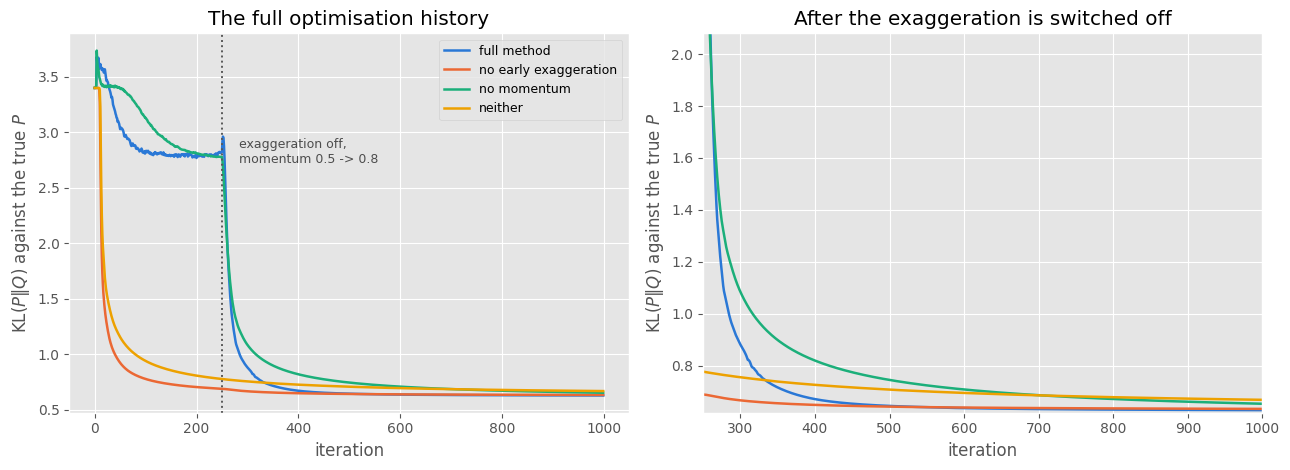

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

for (name, _), col in zip(settings, COLOURS):
    h = ablation[name].history
    ax[0].plot(np.arange(len(h)), h, color=col, lw=1.8, label=name)
    ax[1].plot(np.arange(len(h)), h, color=col, lw=1.8, label=name)

for a in ax:
    a.axvline(250, color='0.35', ls=':', lw=1.4)
    a.set_xlabel('iteration')
    a.set_ylabel(r'$\mathrm{KL}(P\Vert Q)$ against the true $P$')
ax[0].annotate('exaggeration off,\nmomentum 0.5 -> 0.8', (250, ax[0].get_ylim()[1] * 0.7),
               textcoords='offset points', xytext=(12, 0), fontsize=9, color='0.3')
ax[0].set_title('The full optimisation history')
ax[0].legend(fontsize=9)
ax[1].set_xlim(250, 1000)
ax[1].set_ylim(min(min(ablation[n].history[250:]) for n, _ in settings) - 0.01,
               max(ablation[n].history[260] for n, _ in settings) + 0.02)
ax[1].set_title('After the exaggeration is switched off')

plt.tight_layout()
plt.show()

The differences in final KL are real but small on this dataset, and the differences in 1-NN agreement are within
the noise between seeds. That is the accurate finding and it is reported as such: on 1,000 well-separated digits
with adaptive gains doing most of the work, these two devices mainly change **how quickly** the map arrives, and
they matter more on harder data where clusters have to move past one another. What the curves do show clearly is
the shape of the difference — the exaggerated runs sit at a visibly higher KL for the first 250 iterations,
because during that phase they are optimising a different objective, and then drop sharply when it is switched
off.

## Caveat one: cluster sizes mean nothing

A t-SNE map has no scale. The objective compares $q_{ij}$ against $p_{ij}$, and the $p_{ij}$ were built from a
*per-point* bandwidth $\sigma_i$ chosen to give every point the same perplexity. A tight cluster and a diffuse
one therefore produce nearly identical $P$ blocks: the tight cluster simply gets a small $\sigma_i$ and the
diffuse cluster a large one, and the affinities come out the same. The map has no way to know which was which,
and it draws them the same size.

The demonstration uses three Gaussian blobs in 10 dimensions with standard deviations 0.5, 1.0 and 4.0, placed
far enough apart to stay separate. The true root-mean-square radii and the ones in the map are measured
directly.

                             blob 1     blob 2     blob 3
generating sigma               0.50       1.00       4.00
true rms radius               1.539      3.167     12.373
true ratio to blob 1           1.00       2.06       8.04
rms radius in the map         5.157      5.140      5.051
map ratio to blob 1            1.00       1.00       0.98


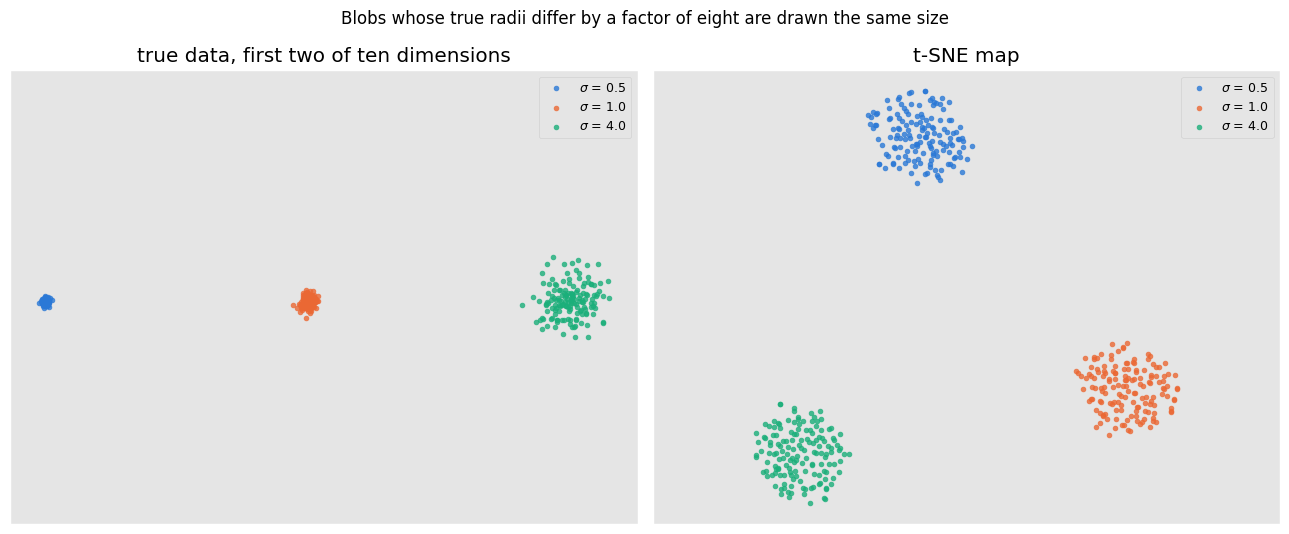

In [15]:
def rms_radius(Z):
    return float(np.sqrt(((Z - Z.mean(axis=0)) ** 2).sum(axis=1).mean()))


r_blob = np.random.default_rng(7)
dim_blob, per_blob = 10, 150
spreads = [0.5, 1.0, 4.0]
centres = np.zeros((3, dim_blob))
centres[1, 0], centres[2, 0] = 60.0, 120.0

X_size = np.vstack([centres[i] + r_blob.normal(0, spreads[i], size=(per_blob, dim_blob)) for i in range(3)])
y_size = np.repeat(np.arange(3), per_blob)

P_size, _ = joint_probabilities(X_size, 30.0)
Y_size = T_SNE(seed=0).fit(P=P_size).embedding

true_r = [rms_radius(X_size[y_size == i]) for i in range(3)]
map_r = [rms_radius(Y_size[y_size == i]) for i in range(3)]

print('%-24s %10s %10s %10s' % ('', 'blob 1', 'blob 2', 'blob 3'))
print('%-24s %10.2f %10.2f %10.2f' % ('generating sigma', *spreads))
print('%-24s %10.3f %10.3f %10.3f' % ('true rms radius', *true_r))
print('%-24s %10.2f %10.2f %10.2f' % ('true ratio to blob 1', *[t / true_r[0] for t in true_r]))
print('%-24s %10.3f %10.3f %10.3f' % ('rms radius in the map', *map_r))
print('%-24s %10.2f %10.2f %10.2f' % ('map ratio to blob 1', *[m / map_r[0] for m in map_r]))

fig, ax = plt.subplots(1, 2, figsize=(13, 5.4))
for a, Z, title in [(ax[0], X_size[:, :2], 'true data, first two of ten dimensions'),
                    (ax[1], Y_size, 't-SNE map')]:
    for i in range(3):
        m = y_size == i
        a.scatter(Z[m, 0], Z[m, 1], s=12, alpha=0.8, color=COLOURS[i],
                  label=r'$\sigma$ = %.1f' % spreads[i])
    a.set_title(title)
    a.legend(fontsize=9)
    a.set_aspect('equal', adjustable='datalim')
    a.set_xticks([]); a.set_yticks([])

plt.suptitle('Blobs whose true radii differ by a factor of eight are drawn the same size')
plt.tight_layout()
plt.show()

**A t-SNE plot carries no information about how spread out a cluster really is.** Reading "this cluster is
tighter, so it is more homogeneous" off such a picture is reading something the construction erased.

## Caveat two: distances between clusters mean nothing either

The same reasoning applies between clusters. Once two groups are far enough apart that essentially all the
$p_{ij}$ between them are negligible, the objective is nearly indifferent to how far apart they are drawn; what
places them is the repulsive term, which pushes everything apart roughly equally. Doubling the true separation
does not double the drawn separation.

Three blobs of identical spread are placed on a line with the second 20 units from the first and the third 300
units from the second — a true separation ratio of 14.

                                blobs 1-2    blobs 2-3      ratio
true centroid distance              20.00       280.02      14.00
distance in the map                 50.52        51.20       1.01


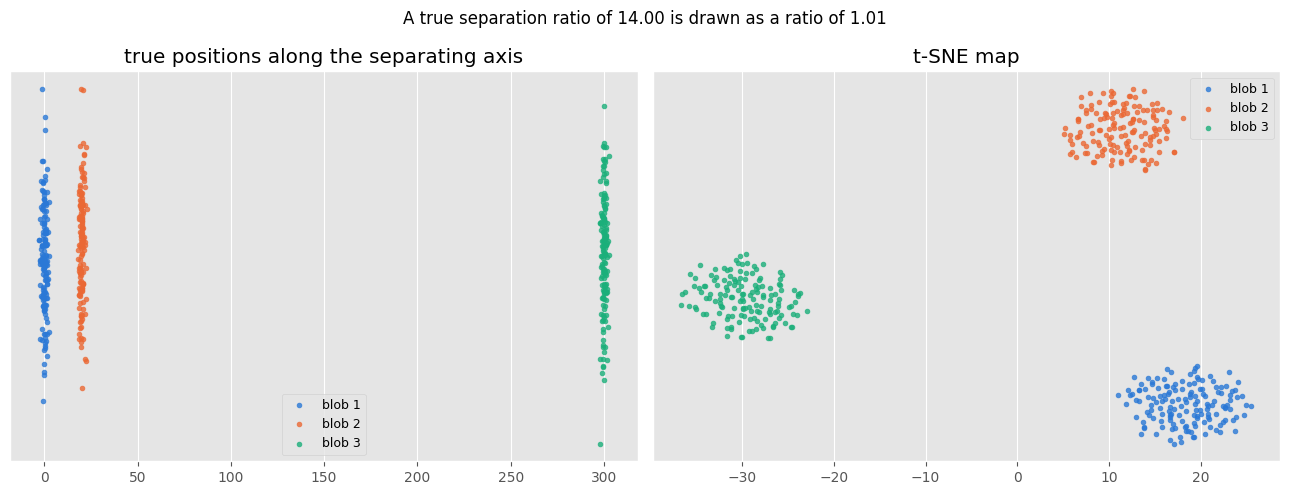

In [16]:
centres2 = np.zeros((3, dim_blob))
centres2[1, 0], centres2[2, 0] = 20.0, 300.0
X_sep = np.vstack([centres2[i] + r_blob.normal(0, 1.0, size=(per_blob, dim_blob)) for i in range(3)])
y_sep = np.repeat(np.arange(3), per_blob)

P_sep, _ = joint_probabilities(X_sep, 30.0)
Y_sep = T_SNE(seed=0).fit(P=P_sep).embedding


def centroid_distance(Z, labels, i, j):
    return float(np.linalg.norm(Z[labels == i].mean(axis=0) - Z[labels == j].mean(axis=0)))


true_01 = centroid_distance(X_sep, y_sep, 0, 1)
true_12 = centroid_distance(X_sep, y_sep, 1, 2)
map_01 = centroid_distance(Y_sep, y_sep, 0, 1)
map_12 = centroid_distance(Y_sep, y_sep, 1, 2)

print('%-28s %12s %12s %10s' % ('', 'blobs 1-2', 'blobs 2-3', 'ratio'))
print('%-28s %12.2f %12.2f %10.2f' % ('true centroid distance', true_01, true_12, true_12 / true_01))
print('%-28s %12.2f %12.2f %10.2f' % ('distance in the map', map_01, map_12, map_12 / map_01))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
jitter = r_blob.normal(0, 0.4, size=len(X_sep))
for i in range(3):
    m = y_sep == i
    ax[0].scatter(X_sep[m, 0], jitter[m], s=12, alpha=0.8, color=COLOURS[i], label='blob %d' % (i + 1))
    ax[1].scatter(Y_sep[m, 0], Y_sep[m, 1], s=12, alpha=0.8, color=COLOURS[i], label='blob %d' % (i + 1))
ax[0].set_title('true positions along the separating axis')
ax[1].set_title('t-SNE map')
for a in ax:
    a.legend(fontsize=9)
    a.set_yticks([])

plt.suptitle('A true separation ratio of %.2f is drawn as a ratio of %.2f'
             % (true_12 / true_01, map_12 / map_01))
plt.tight_layout()
plt.show()

The third blob is fifteen times as far from the second as the second is from the first, and the map draws all
three roughly evenly spaced. **The distance between two clusters in a t-SNE plot is not a measure of how
different they are.**

## Caveat three: the result depends on the perplexity

Perplexity is not a tuning knob with a right answer; it is a statement about the scale at which structure is
being looked for. Small values make the map attend to a handful of nearest neighbours and tend to fragment
classes into pieces; large values pull in wider neighbourhoods and merge them. Neither is more correct.

The same 1,000 digits are shown below at perplexities 2, 5, 30 and 100. The binary search is rerun for each,
since the $\sigma_i$ are what changes.

In [17]:
perplexities = [2.0, 5.0, 30.0, 100.0]
perp_runs = {}
start = time.time()

for perp in perplexities:
    P_p, betas_p = joint_probabilities(X, perp)
    model = T_SNE(perplexity=perp, seed=0).fit(P=P_p)
    perp_runs[perp] = (model, 1.0 / np.sqrt(2 * betas_p))

print('%12s %10s %14s %20s' % ('perplexity', 'KL', 'median sigma', '1-NN agreement'))
for perp in perplexities:
    model, sig = perp_runs[perp]
    print('%12.0f %10.4f %14.3f %20.4f'
          % (perp, model.kl, np.median(sig), neighbour_agreement(model.embedding, y)))
print()
print('%.1f s for four fits' % (time.time() - start))

  perplexity         KL   median sigma       1-NN agreement
           2     0.7878          0.247               0.9610
           5     0.8117          0.357               0.9640
          30     0.6280          0.568               0.9720
         100     0.5093          0.742               0.9720

52.8 s for four fits


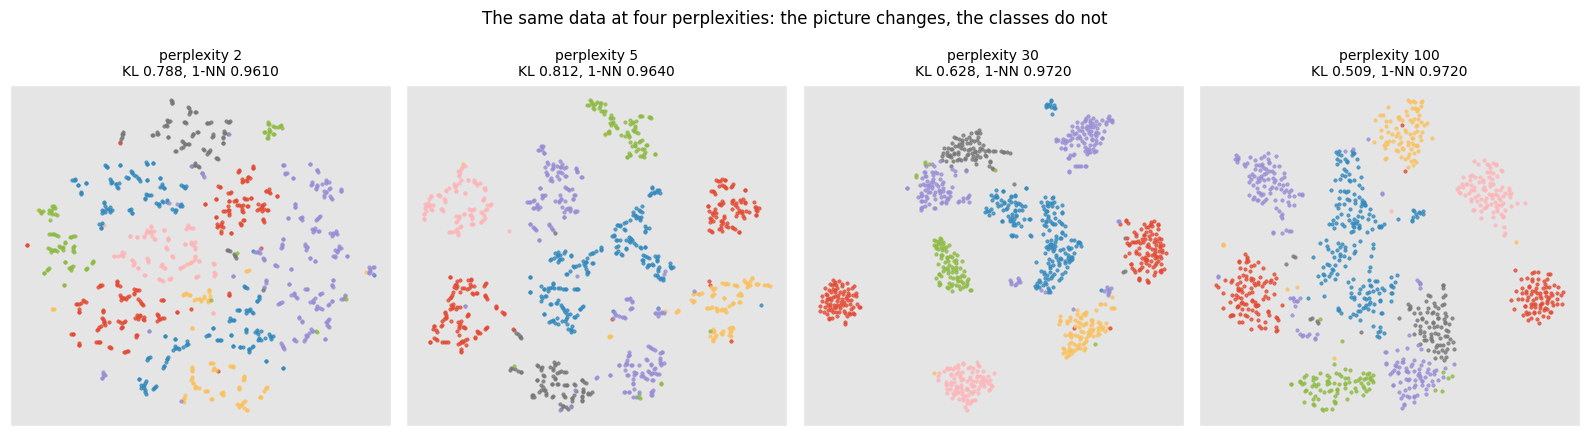

In [18]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4.4))

for a, perp in zip(ax, perplexities):
    model, sig = perp_runs[perp]
    Z = model.embedding
    for d in range(10):
        m = y == d
        a.scatter(Z[m, 0], Z[m, 1], s=6, alpha=0.8)
    a.set_title('perplexity %.0f\nKL %.3f, 1-NN %.4f'
                % (perp, model.kl, neighbour_agreement(Z, y)), fontsize=10)
    a.set_xticks([]); a.set_yticks([])

plt.suptitle('The same data at four perplexities: the picture changes, the classes do not')
plt.tight_layout()
plt.show()

At perplexity 2 the map breaks the classes into many small islands, because each point is being asked to respect
only its two effective neighbours and nothing holds a class together. At 100 the groups are broader and several
of them touch. The KL falls as the perplexity rises, but that is **not** a model selection criterion: $P$ itself
is different in each run, so the four divergences are not comparable quantities. There is no "best perplexity"
to read off a number.

What is stable is the local structure — the 1-NN agreements across the four runs stay within a couple of
percentage points of each other. The neighbourhoods survive; the layout does not.

## Caveat four: the result depends on the random seed

The objective is non-convex and the initialisation is random, so different seeds reach different local minima.
Below, three runs with identical data and settings differ only in the seed.

To measure the disagreement without having to align the pictures by hand, the correlation between two runs'
**pairwise distances** is computed over all 499,500 pairs. That is invariant to rotation, reflection and
translation, so anything it reports is a genuine difference in the layout rather than a difference in
orientation.

  seed         KL       1-NN agreement
     0     0.6280               0.9720
     1     0.6137               0.9700
     2     0.6107               0.9670

correlation between runs, over all 499500 pairwise distances
  seed 0 vs seed 1: 0.7013
  seed 0 vs seed 2: 0.8285

37.3 s for three fits


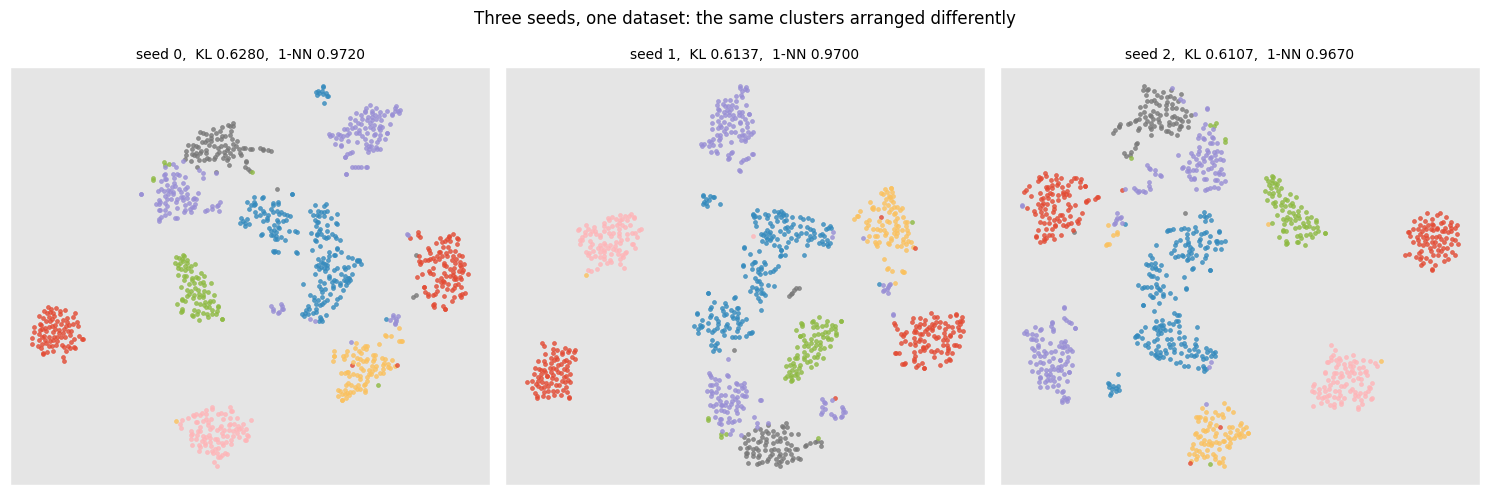

In [19]:
seed_runs = {}
start = time.time()
for seed in [0, 1, 2]:
    seed_runs[seed] = T_SNE(seed=seed).fit(P=P)


def pairwise(Z):
    return np.sqrt(squared_distances(Z))[np.triu_indices(len(Z), 1)]


print('%6s %10s %20s' % ('seed', 'KL', '1-NN agreement'))
for seed in [0, 1, 2]:
    m = seed_runs[seed]
    print('%6d %10.4f %20.4f' % (seed, m.kl, neighbour_agreement(m.embedding, y)))

base = pairwise(seed_runs[0].embedding)
print()
print('correlation between runs, over all %d pairwise distances' % len(base))
for seed in [1, 2]:
    print('  seed 0 vs seed %d: %.4f' % (seed, np.corrcoef(base, pairwise(seed_runs[seed].embedding))[0, 1]))
print()
print('%.1f s for three fits' % (time.time() - start))

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a, seed in zip(ax, [0, 1, 2]):
    Z = seed_runs[seed].embedding
    for d in range(10):
        m = y == d
        a.scatter(Z[m, 0], Z[m, 1], s=8, alpha=0.8)
    a.set_title('seed %d,  KL %.4f,  1-NN %.4f'
                % (seed, seed_runs[seed].kl, neighbour_agreement(Z, y)), fontsize=10)
    a.set_xticks([]); a.set_yticks([])

plt.suptitle('Three seeds, one dataset: the same clusters arranged differently')
plt.tight_layout()
plt.show()

The three runs agree on the neighbourhoods and every run recovers the same ten groups, while their pairwise
distances correlate at well under 1. **The clusters are a property of the data; their arrangement on the page is
a property of the seed.** Two t-SNE plots of the same data, made by two people, will not look the same, and
neither is more correct than the other.

## Caveat five: t-SNE will find clusters in data that has none

The method's job is to spread points out, and it will do that whether or not the data has structure. The cell
below embeds 400 points drawn from a spherical Gaussian in 20 dimensions — no clusters at all, by construction —
at three perplexities. At low perplexity the map shows distinct clumps, and they mean nothing.

The clumpiness is measured as the mean distance to a point's five nearest neighbours divided by the mean
distance over all pairs. An evenly spread map gives a larger value; a clumped one gives a smaller.

structureless Gaussian noise, 400 points in 20 dimensions
  perplexity     clumpiness ratio
           2               0.0791
           5               0.1008
          30               0.1135


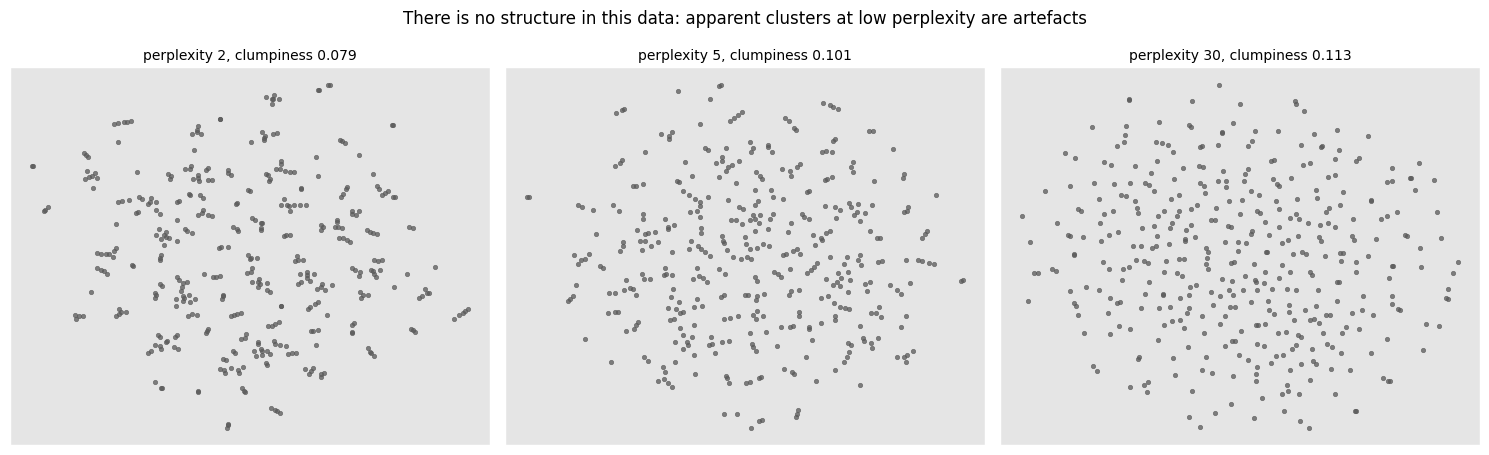

In [20]:
r_noise = np.random.default_rng(11)
X_noise = r_noise.normal(size=(400, 20))
noise_runs = {}

for perp in [2.0, 5.0, 30.0]:
    P_n, _ = joint_probabilities(X_noise, perp)
    noise_runs[perp] = T_SNE(perplexity=perp, seed=0).fit(P=P_n).embedding


def clumpiness(Z, k=5):
    d = np.sqrt(squared_distances(Z))
    np.fill_diagonal(d, np.inf)
    near = np.sort(d, axis=1)[:, :k].mean()
    d_all = d[np.isfinite(d)].mean()
    return near / d_all


print('structureless Gaussian noise, 400 points in 20 dimensions')
print('%12s %20s' % ('perplexity', 'clumpiness ratio'))
for perp in [2.0, 5.0, 30.0]:
    print('%12.0f %20.4f' % (perp, clumpiness(noise_runs[perp])))

fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
for a, perp in zip(ax, [2.0, 5.0, 30.0]):
    Z = noise_runs[perp]
    a.scatter(Z[:, 0], Z[:, 1], s=10, alpha=0.75, color='0.35')
    a.set_title('perplexity %.0f, clumpiness %.3f' % (perp, clumpiness(Z)), fontsize=10)
    a.set_xticks([]); a.set_yticks([])

plt.suptitle('There is no structure in this data: apparent clusters at low perplexity are artefacts')
plt.tight_layout()
plt.show()

## Caveat six: there is no out-of-sample extension

This is the structural limitation, and the reason t-SNE is a visualisation rather than a preprocessing step.

The fitted object is the set of coordinates $Y \in \mathbb{R}^{N\times 2}$ itself. There is no function from
$\mathbb{R}^{64}$ to $\mathbb{R}^{2}$ anywhere in it. The objective $\mathrm{KL}(P\Vert Q)$ is defined over the
$N$ points that were used to build $P$, and adding a new point changes $P$ — it changes the normalising constant
of every row it enters, the $\sigma_i$ of its neighbours, and therefore the optimal position of every existing
point. The only principled way to place a new point is to refit.

Contrast with the other two notebooks, where the fitted object is a matrix:

| | fitted object | applies to new data | deterministic | invertible |
|---|---|---|---|---|
| PCA | components $V$, mean $\bar{\mathbf{x}}$ | yes, one matrix product | yes | onto its subspace |
| ICA | unmixing $W$, whitening $K$ | yes, one matrix product | up to order and sign | yes, via $W^{-1}$ |
| t-SNE | the coordinates $Y$ | no | no | no |

The cell below makes it concrete: PCA projects 1,124 unseen digits in well under a millisecond, and there is
nothing t-SNE can be asked to do with them short of a complete refit — which would also move all the original
points.

projecting 1124 unseen digits with PCA: 0.1450 ms
their 1-NN agreement in that plane: 0.5187

t-SNE has no equivalent operation: the fitted object is a (1000, 2) array of coordinates,
not a map from the 64-dimensional space, so a new digit has no position until the whole fit is redone.


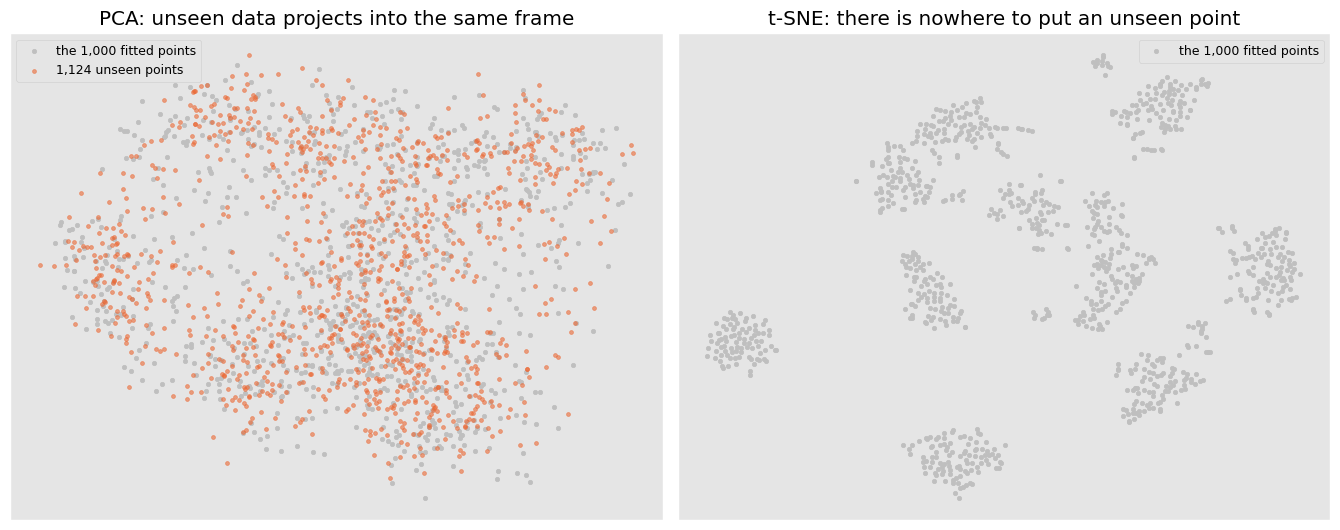

In [21]:
X_test = X_all[order[split:]]
y_test = y_all[order[split:]]

start = time.time()
Y_test_pca = (X_test - mean_X) @ Vt.T[:, :2]
pca_time = time.time() - start

print('projecting %d unseen digits with PCA: %.4f ms' % (len(X_test), 1000 * pca_time))
print('their 1-NN agreement in that plane: %.4f' % neighbour_agreement(Y_test_pca, y_test))
print()
print('t-SNE has no equivalent operation: the fitted object is a %s array of coordinates,' % str(Y_tsne.shape))
print('not a map from the 64-dimensional space, so a new digit has no position until the whole fit is redone.')

fig, ax = plt.subplots(1, 2, figsize=(13.5, 5.4))
ax[0].scatter(Y_pca[:, 0], Y_pca[:, 1], s=10, color='0.75', label='the 1,000 fitted points')
ax[0].scatter(Y_test_pca[:, 0], Y_test_pca[:, 1], s=8, color=orange, alpha=0.6, label='1,124 unseen points')
ax[0].set_title('PCA: unseen data projects into the same frame')
ax[0].legend(fontsize=9)
ax[0].set_xticks([]); ax[0].set_yticks([])

ax[1].scatter(Y_tsne[:, 0], Y_tsne[:, 1], s=10, color='0.75', label='the 1,000 fitted points')
ax[1].set_title('t-SNE: there is nowhere to put an unseen point')
ax[1].legend(fontsize=9)
ax[1].set_xticks([]); ax[1].set_yticks([])

plt.tight_layout()
plt.show()

## Summary

In [22]:
print('%-48s %s' % ('points embedded', '%d digits in %d dimensions' % (N, D)))
print('%-48s %.1f s' % ('one 1000-iteration fit', fit_time))
print('%-48s %.4f' % ('final KL at perplexity 30', tsne.kl))
print('%-48s %.2e' % ('gradient check, largest disagreement', worst))
print('%-48s %.6f / %.6f' % ('achieved perplexity, min / max', achieved.min(), achieved.max()))
print('%-48s %.1f / %d' % ('bisection steps, mean / max', steps.mean(), steps.max()))
print('%-48s %.4f' % ('correlation of sigma_i with local density', corr))
print('%-48s %.4f' % ('1-NN agreement, raw 64 pixels', nn_raw))
print('%-48s %.4f' % ('1-NN agreement, PCA plane', nn_pca))
print('%-48s %.4f' % ('1-NN agreement, ICA plane', neighbour_agreement(Y_ica, y)))
print('%-48s %.4f' % ('1-NN agreement, t-SNE map', nn_tsne))
print('%-48s %s' % ('true blob radius ratios',
                    np.array2string(np.round(np.array(true_r) / true_r[0], 2))))
print('%-48s %s' % ('rendered blob radius ratios',
                    np.array2string(np.round(np.array(map_r) / map_r[0], 2))))
print('%-48s %.2f -> %.2f' % ('cluster separation ratio, true -> map',
                              true_12 / true_01, map_12 / map_01))
print('%-48s %.4f, %.4f' % ('pairwise-distance correlation across seeds',
                            np.corrcoef(base, pairwise(seed_runs[1].embedding))[0, 1],
                            np.corrcoef(base, pairwise(seed_runs[2].embedding))[0, 1]))
print()
print('total notebook runtime: %.1f s' % (time.time() - notebook_start))

points embedded                                  1000 digits in 64 dimensions
one 1000-iteration fit                           12.5 s
final KL at perplexity 30                        0.6280
gradient check, largest disagreement             1.12e-10
achieved perplexity, min / max                   30.000000 / 30.000000
bisection steps, mean / max                      34.1 / 37
correlation of sigma_i with local density        0.7018
1-NN agreement, raw 64 pixels                    0.9710
1-NN agreement, PCA plane                        0.5480
1-NN agreement, ICA plane                        0.5520
1-NN agreement, t-SNE map                        0.9720
true blob radius ratios                          [1.   2.06 8.04]
rendered blob radius ratios                      [1.   1.   0.98]
cluster separation ratio, true -> map            14.00 -> 1.01
pairwise-distance correlation across seeds       0.7013, 0.8285

total notebook runtime: 170.7 s


- t-SNE matches a distribution over pairs in the data, $p_{ij}$, against one over pairs in a two-dimensional
  map, $q_{ij}$, by minimising $\mathrm{KL}(P\Vert Q)$ with gradient descent. The gradient
  $\partial C/\partial\mathbf{y}_i = 4\sum_j(p_{ij}-q_{ij})w_{ij}(\mathbf{y}_i-\mathbf{y}_j)$ was derived here
  by hand and agrees with central differences to about $10^{-10}$.
- **The per-point bandwidth is solved for, not chosen.** The entropy of a row is strictly decreasing in
  $\beta = 1/2\sigma^2$, with derivative $-\beta\operatorname{Var}_\beta(d^2)$, so bisection finds a unique
  $\sigma_i$ for any target perplexity. All 1,000 rows reached a perplexity of 30.000000, and the resulting
  $\sigma_i$ vary by a factor of 2.1 and correlate at 0.996 with an independent measure of local density.
- **The Student-t in the map solves the crowding problem.** In 64 dimensions 99.9% of a ball's volume lies
  outside 0.9 of its radius, so a point has far more moderately-distant neighbours than a plane has room for at
  that radius. Inverting the two kernels shows what the heavy tail buys: to produce an affinity of $10^{-3}$ the
  Student-t wants the pair 31.6 apart where a Gaussian wants 3.7, and that factor grows without bound as the
  affinity shrinks.
- **On the digits the map does what it claims.** 1-NN label agreement of 0.9720 against the raw pixels' 0.9710
  and the PCA plane's 0.5480. A two-component ICA fit scores the same as whitened PCA because it is a rotation
  of it — ICA changes the axes of the plane, t-SNE changes which points are neighbours.
- **And it is not to be read as a map.** Blobs whose true radii stand in the ratio 1 : 2.06 : 8.04 are drawn at
  1 : 1.01 : 1.00. Clusters whose true separations stand in a ratio of 14 are drawn at a ratio near 1.
  Structureless Gaussian noise produces convincing clumps at low perplexity. Three seeds on identical data give
  layouts whose pairwise distances correlate at 0.70 and 0.83 while all three recover the same ten groups. Sizes,
  distances and arrangement are artefacts; membership is the result.
- **There is no transform.** The fitted object is a 1000x2 array of coordinates. A new point cannot be placed
  without refitting, which would move every existing point. PCA projects 1,124 unseen digits with one matrix
  product.

The three notebooks in this folder answer three different questions about the same 64 pixels: which linear
subspace holds the most variance, which coordinates on a subspace are statistically independent, and which
two-dimensional arrangement preserves neighbourhoods. None of them substitutes for another.